# Lab 2: Cats vs Dogs

In this lab, you will train a convolutional neural network to classify an image 
into one of two classes: "cat" or "dog". The code for the neural networks 
you train will be written for you, and you are not (yet!) expected
to understand all provided code. However, by the end of the lab,
you should be able to:

1. Understand at a high level the training loop for a machine learning model.
2. Understand the distinction between training, validation, and test data.
3. The concepts of overfitting and underfitting.
4. Investigate how different hyperparameters, such as learning rate and batch size, affect the success of training.
5. Compare an ANN (aka Multi-Layer Perceptron) with a CNN.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to **File > Print** and then save as PDF. The Colab instructions
has more information.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

With Colab, you can export a PDF file using the menu option
`File -> Print` and save as PDF file. **Adjust the scaling to ensure that the text is not cutoff at the margins.**

## Colab Link

Include a link to your colab file here

Colab Link: https://colab.research.google.com/github/Ibrahim925/aps360-labs/blob/master/Lab%202/Lab2_Cats_vs_Dogs.ipynb

In [2]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms


## Part 0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [3]:
###############################################################################
# Data Loading

def get_relevant_indices(dataset, classes, target_classes):
    """ Return the indices for datapoints in the dataset that belongs to the
    desired target classes, a subset of all possible classes.

    Args:
        dataset: Dataset object
        classes: A list of strings denoting the name of each class
        target_classes: A list of strings denoting the name of desired classes
                        Should be a subset of the 'classes'
    Returns:
        indices: list of indices that have labels corresponding to one of the
                 target classes
    """
    indices = []
    for i in range(len(dataset)):
        # Check if the label is in the target classes
        label_index = dataset[i][1] # ex: 3
        label_class = classes[label_index] # ex: 'cat'
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    """ Loads images of cats and dogs, splits the data into training, validation
    and testing datasets. Returns data loaders for the three preprocessed datasets.

    Args:
        target_classes: A list of strings denoting the name of the desired
                        classes. Should be a subset of the argument 'classes'
        batch_size: A int representing the number of samples per batch

    Returns:
        train_loader: iterable training dataset organized according to batch size
        val_loader: iterable validation dataset organized according to batch size
        test_loader: iterable testing dataset organized according to batch size
        classes: A list of strings denoting the name of each class
    """

    classes = ('plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    ########################################################################
    # The output of torchvision datasets are PILImage images of range [0, 1].
    # We transform them to Tensors of normalized range [-1, 1].
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    # Load CIFAR10 training data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_indices = get_relevant_indices(trainset, classes, target_classes)

    # Split into train and validation
    np.random.seed(1000) # Fixed numpy random seed for reproducible shuffling
    np.random.shuffle(relevant_indices)
    split = int(len(relevant_indices) * 0.8) #split at 80%

    # split into training and validation indices
    relevant_train_indices, relevant_val_indices = relevant_indices[:split], relevant_indices[split:]
    train_sampler = SubsetRandomSampler(relevant_train_indices)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               num_workers=1, sampler=train_sampler)
    val_sampler = SubsetRandomSampler(relevant_val_indices)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              num_workers=1, sampler=val_sampler)
    # Load CIFAR10 testing data
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_test_indices = get_relevant_indices(testset, classes, target_classes)
    test_sampler = SubsetRandomSampler(relevant_test_indices)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = normalize_label(labels)  # Convert labels to 0/1
        outputs = net(inputs)
        loss = criterion(outputs, labels.float())
        corr = (outputs > 0.0).squeeze().long() != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

## Part 1. Visualizing the Data [7 pt]

We will make use of some of the CIFAR-10 data set, which consists of 
colour images of size 32x32 pixels belonging to 10 categories. You can
find out more about the dataset at https://www.cs.toronto.edu/~kriz/cifar.html

For this assignment, we will only be using the cat and dog categories. 
We have included code that automatically downloads the dataset the 
first time that the main script is run.

In [4]:
# This will download the CIFAR-10 dataset to a folder called "data"
# the first time you run this code.
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"],
    batch_size=1) # One image per batch

100.0%


### Part (a) -- 1 pt

Visualize some of the data by running the code below.
Include the visualization in your writeup.

(You don't need to submit anything else.)

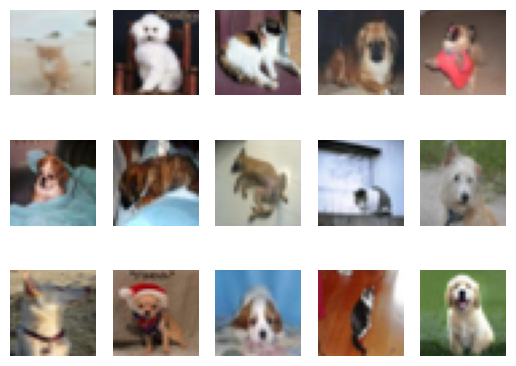

In [6]:
import matplotlib.pyplot as plt

k = 0
for images, labels in train_loader:
    # since batch_size = 1, there is only 1 image in `images`
    image = images[0]
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
    img = img / 2 + 0.5
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 14:
        break

### Part (b) -- 3 pt

How many training examples do we have for the combined `cat` and `dog` classes? 
What about validation examples? 
What about test examples?

In [7]:
train_examples = len(train_loader.sampler)
val_examples = len(val_loader.sampler)
test_examples = len(test_loader.sampler)

print(f"Training examples: {train_examples}")
print(f"Validation examples: {val_examples}")
print(f"Test examples: {test_examples}")

Training examples: 8000
Validation examples: 2000
Test examples: 2000


### Part (c) -- 3pt

Why do we need a validation set when training our model? What happens if we judge the 
performance of our models using the training set loss/error instead of the validation
set loss/error?

We need a validation set because it acts as an independent checkpoint to evaluate how well a model generalizes to new, unseen data during training. If we judge performance using the training loss instead of the validation loss, we run into the massive trap of overfitting. The training loss only measures how well the model has memorized the specific examples it was fed, meaning a model can achieve a perfect 0% training error simply by learning the "noise" and quirks of that specific dataset rather than the underlying patterns. By relying solely on training error, you will likely choose an overly complex, brittle model that performs flawlessly on paper but fails spectacularly when deployed in the real world.

## Part 2. Training [15 pt]

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [8]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [9]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 7 * 7, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 7 * 7)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [10]:
small_net = SmallNet()
large_net = LargeNet()

### Part (a) -- 2pt

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values. 

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

In [11]:
small_params = sum(p.numel() for p in small_net.parameters())
large_params = sum(p.numel() for p in large_net.parameters())

print(f"small_net total parameters: {small_params}")
print(f"large_net total parameters: {large_params}")

small_net total parameters: 386
large_net total parameters: 9705


### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [12]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on cats vs dogs
    target_classes = ["cat", "dog"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible result
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            target_classes, batch_size)
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Binary Cross Entropy (BCE). In this case we
    # will use the BCEWithLogitsLoss which takes unnormalized output from
    # the neural network and scalar label.
    # Optimizer will be SGD with Momentum.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            labels = normalize_label(labels) # Convert labels to 0/1
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            corr = (outputs > 0.0).squeeze().long() != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

### Part (b) -- 1pt

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on. 

What are the default values of the parameters `batch_size`, `learning_rate`, 
and `num_epochs`?

batch_size=64, learning_rate=0.01, num_epochs=30

### Part (c) -- 3 pt

What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.

In [13]:
train_net(small_net, num_epochs=5)

Epoch 1: Train err: 0.412, Train loss: 0.6696354351043701 |Validation err: 0.3855, Validation loss: 0.6560668107122183
Epoch 2: Train err: 0.368375, Train loss: 0.6473523664474488 |Validation err: 0.3835, Validation loss: 0.6616278681904078
Epoch 3: Train err: 0.348625, Train loss: 0.6290214443206787 |Validation err: 0.337, Validation loss: 0.6186341363936663
Epoch 4: Train err: 0.333875, Train loss: 0.6115366997718811 |Validation err: 0.3425, Validation loss: 0.6166160926222801
Epoch 5: Train err: 0.32275, Train loss: 0.6026374514102936 |Validation err: 0.3265, Validation loss: 0.6058014314621687
Finished Training
Total time elapsed: 62.48 seconds


### Model weights after each epoch:
model_small_bs64_lr0.01_epoch0

model_small_bs64_lr0.01_epoch1

model_small_bs64_lr0.01_epoch2

model_small_bs64_lr0.01_epoch3

model_small_bs64_lr0.01_epoch4

### Model error and loss across epochs:
model_small_bs64_lr0.01_epoch4_train_err.csv

model_small_bs64_lr0.01_epoch4_train_loss.csv

model_small_bs64_lr0.01_epoch4_val_err.csv

model_small_bs64_lr0.01_epoch4_val_loss.csv


### Part (d) -- 2pt

Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights) 
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive 
so that the files generated by `train_net` gets saved. We will be using
these files in part (d).
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?

The large network took longer to train since it has more parameters to learn.

In [19]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the lab locally, you
# can comment out this code.

# from google.colab import drive
# drive.mount('/content/gdrive')

train_net(small_net) # Took 371.32 seconds

Epoch 1: Train err: 0.318, Train loss: 0.5917263994216919 |Validation err: 0.3195, Validation loss: 0.6009899750351906
Epoch 2: Train err: 0.306625, Train loss: 0.5840075914859771 |Validation err: 0.3215, Validation loss: 0.6138012818992138
Epoch 3: Train err: 0.302625, Train loss: 0.5768458805084229 |Validation err: 0.3025, Validation loss: 0.5866450127214193
Epoch 4: Train err: 0.297875, Train loss: 0.5678414919376373 |Validation err: 0.3175, Validation loss: 0.5947845950722694
Epoch 5: Train err: 0.292625, Train loss: 0.56221444606781 |Validation err: 0.3, Validation loss: 0.5806322675198317
Epoch 6: Train err: 0.291625, Train loss: 0.555599267244339 |Validation err: 0.304, Validation loss: 0.5833760360255837
Epoch 7: Train err: 0.28675, Train loss: 0.5538951952457428 |Validation err: 0.2895, Validation loss: 0.5716577870771289
Epoch 8: Train err: 0.28925, Train loss: 0.5494103713035583 |Validation err: 0.292, Validation loss: 0.5666538178920746
Epoch 9: Train err: 0.280875, Train l

In [20]:
train_net(large_net) # 388.98 seconds

Epoch 1: Train err: 0.474125, Train loss: 0.6902968158721924 |Validation err: 0.4595, Validation loss: 0.6873084548860788
Epoch 2: Train err: 0.444625, Train loss: 0.6843374032974243 |Validation err: 0.432, Validation loss: 0.6879162769764662
Epoch 3: Train err: 0.429, Train loss: 0.6775988659858704 |Validation err: 0.4045, Validation loss: 0.6742942649871111
Epoch 4: Train err: 0.41125, Train loss: 0.6662742595672607 |Validation err: 0.379, Validation loss: 0.6574750393629074
Epoch 5: Train err: 0.38075, Train loss: 0.6551531805992127 |Validation err: 0.3785, Validation loss: 0.6498497165739536
Epoch 6: Train err: 0.367, Train loss: 0.6383155651092529 |Validation err: 0.376, Validation loss: 0.6527630090713501
Epoch 7: Train err: 0.349125, Train loss: 0.6272312912940979 |Validation err: 0.3505, Validation loss: 0.6242398601025343
Epoch 8: Train err: 0.338375, Train loss: 0.6078400726318359 |Validation err: 0.329, Validation loss: 0.6128855142742395
Epoch 9: Train err: 0.32, Train loss

### Part (e) - 2pt

Use the function `plot_training_curve` to display the trajectory of the 
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.

In [21]:
small_path = get_model_name("small", batch_size=64, learning_rate=0.01, epoch=29)
large_path = get_model_name("large", batch_size=64, learning_rate=0.01, epoch=29)

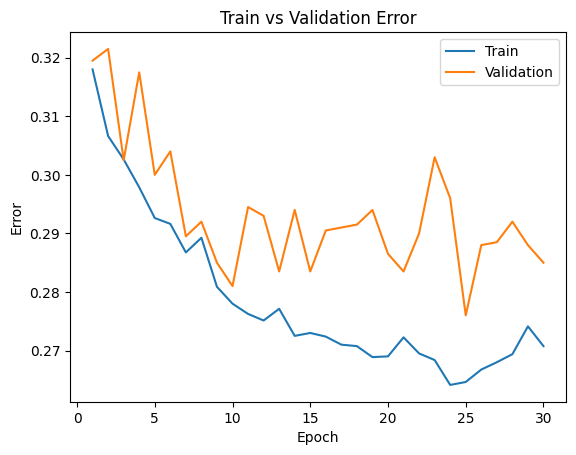

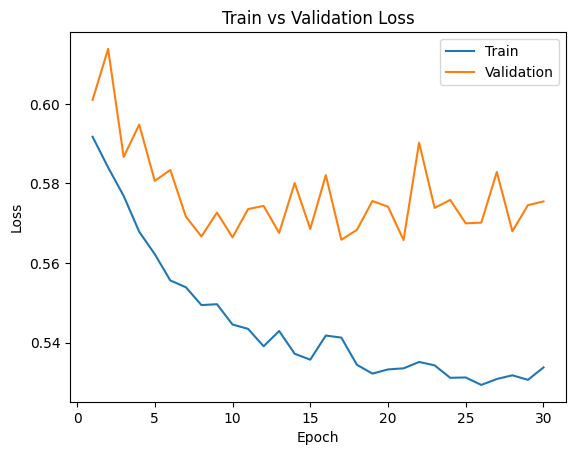

In [22]:
plot_training_curve(small_path)

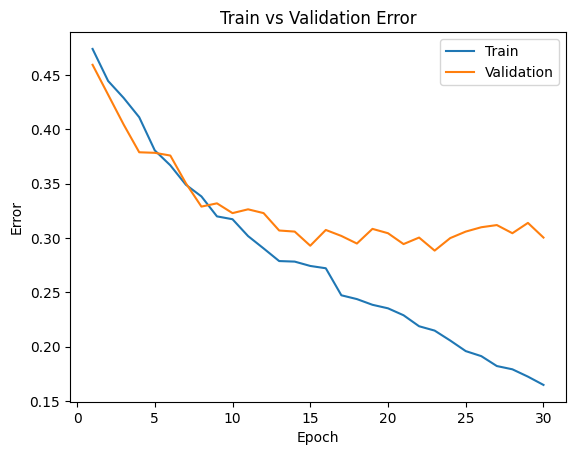

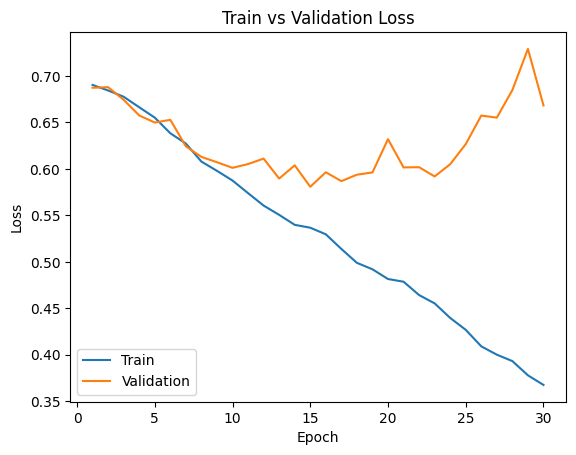

In [23]:
plot_training_curve(large_path)

### Part (f) - 5pt

Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.

The training curves for both networks decrease steadily across all 30 epochs, though the large_net drives training loss and error significantly lower than the small_net due to its higher capacity. However, this extra capacity does not translate to better generalization: while the small_net exhibits moderate overfitting starting around epoch 10—where its validation metrics plateau and oscillate horizontally while training continues to improve—the large_net suffers from severe overfitting. This is most evident in the large_net loss plot, where a sharp divergence occurs after epoch 15; the training loss plunges while the validation loss takes a distinct U-turn upward, signaling that the larger model is aggressively memorizing noise in the training data rather than learning generalizable features. Early epochs (1–5) show brief, typical underfitting as both models initialize with high errors, but neither network remains underfit as training progresses.

## Part 3. Optimization Parameters [12 pt]

For this section, we will work with `large_net` only.

### Part (a) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.

In [17]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()

In [25]:
train_net(large_net, learning_rate=0.001)

Epoch 1: Train err: 0.118625, Train loss: 0.2966440999507904 |Validation err: 0.302, Validation loss: 0.7065231269225478
Epoch 2: Train err: 0.109625, Train loss: 0.2771827574968338 |Validation err: 0.298, Validation loss: 0.7182354666292667
Epoch 3: Train err: 0.103375, Train loss: 0.26932036542892457 |Validation err: 0.3, Validation loss: 0.7370492797344923
Epoch 4: Train err: 0.101125, Train loss: 0.26359734880924224 |Validation err: 0.297, Validation loss: 0.7488192748278379
Epoch 5: Train err: 0.100125, Train loss: 0.25914119291305543 |Validation err: 0.3005, Validation loss: 0.7810786291956902
Epoch 6: Train err: 0.097875, Train loss: 0.2539409314393997 |Validation err: 0.3, Validation loss: 0.7659496981650591
Epoch 7: Train err: 0.096125, Train loss: 0.2501260977983475 |Validation err: 0.303, Validation loss: 0.7706592772156
Epoch 8: Train err: 0.093375, Train loss: 0.24644570362567902 |Validation err: 0.3055, Validation loss: 0.7910341713577509
Epoch 9: Train err: 0.092125, Tra

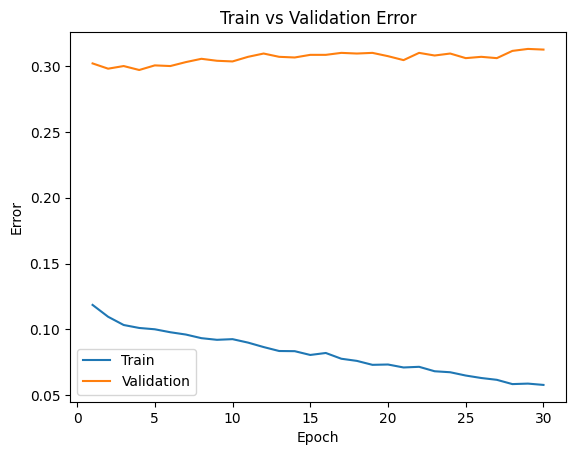

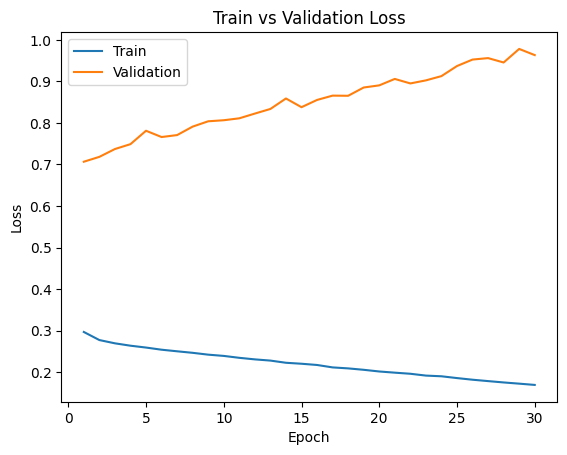

In [26]:
large_path = get_model_name("large", batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(large_path)

The model takes about the same time to train. The train curves are far smoother. The model severely overfits. As training progresses, the model becomes overconfident in its incorrect predictions on the validation set.

### Part (b) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.1`. 
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.

In [28]:
large_net = LargeNet()
train_net(large_net, learning_rate=0.1)

Epoch 1: Train err: 0.428875, Train loss: 0.6740304770469665 |Validation err: 0.367, Validation loss: 0.6355955991894007
Epoch 2: Train err: 0.363375, Train loss: 0.6375216073989868 |Validation err: 0.3545, Validation loss: 0.6257855147123337
Epoch 3: Train err: 0.36075, Train loss: 0.6283564453125 |Validation err: 0.3375, Validation loss: 0.6151857692748308
Epoch 4: Train err: 0.34275, Train loss: 0.6129759335517884 |Validation err: 0.3465, Validation loss: 0.6281368415802717
Epoch 5: Train err: 0.32575, Train loss: 0.599629560470581 |Validation err: 0.3375, Validation loss: 0.6072611659765244
Epoch 6: Train err: 0.3145, Train loss: 0.5799939982891082 |Validation err: 0.335, Validation loss: 0.6243442250415683
Epoch 7: Train err: 0.302875, Train loss: 0.5700533511638641 |Validation err: 0.3165, Validation loss: 0.5744068240746856
Epoch 8: Train err: 0.2895, Train loss: 0.5511445660591126 |Validation err: 0.334, Validation loss: 0.6125903315842152
Epoch 9: Train err: 0.29325, Train los

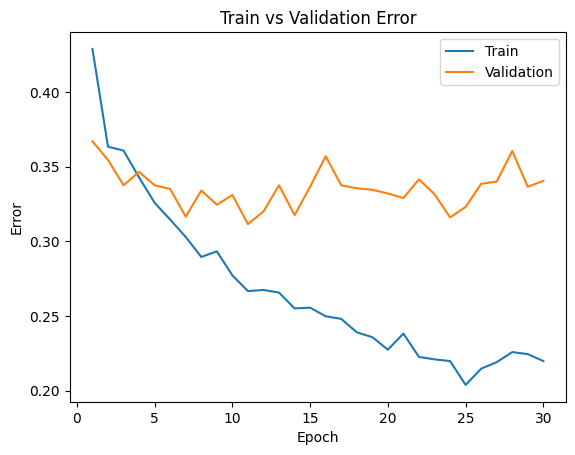

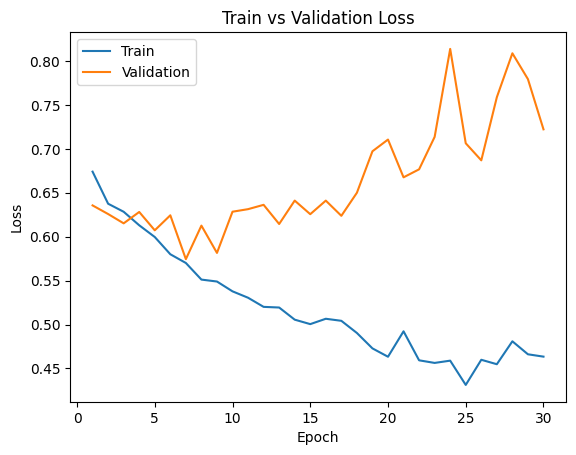

In [29]:
large_path = get_model_name("large", batch_size=64, learning_rate=0.1, epoch=29)

plot_training_curve(large_path)

Model takes longer to train. Curves are less smooth. Since the learning rate is higher, learning is more volatile since it can easily overshoot, creating more noise. After a few epochs, the model begins to overfit drastically.

### Part (c) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.

In [30]:
large_net = LargeNet()
train_net(large_net, batch_size=512)

Epoch 1: Train err: 0.48175, Train loss: 0.6929379515349865 |Validation err: 0.478, Validation loss: 0.6926823556423187
Epoch 2: Train err: 0.457625, Train loss: 0.6924104019999504 |Validation err: 0.434, Validation loss: 0.6917425394058228
Epoch 3: Train err: 0.437, Train loss: 0.691650040447712 |Validation err: 0.4265, Validation loss: 0.6909129023551941
Epoch 4: Train err: 0.433625, Train loss: 0.6908449269831181 |Validation err: 0.424, Validation loss: 0.6897872388362885
Epoch 5: Train err: 0.433875, Train loss: 0.6896937862038612 |Validation err: 0.424, Validation loss: 0.688135951757431
Epoch 6: Train err: 0.438375, Train loss: 0.6883536539971828 |Validation err: 0.4285, Validation loss: 0.6860135644674301
Epoch 7: Train err: 0.439375, Train loss: 0.6866878680884838 |Validation err: 0.426, Validation loss: 0.6836971044540405
Epoch 8: Train err: 0.435375, Train loss: 0.6849774345755577 |Validation err: 0.4115, Validation loss: 0.6814664453268051
Epoch 9: Train err: 0.42375, Train 

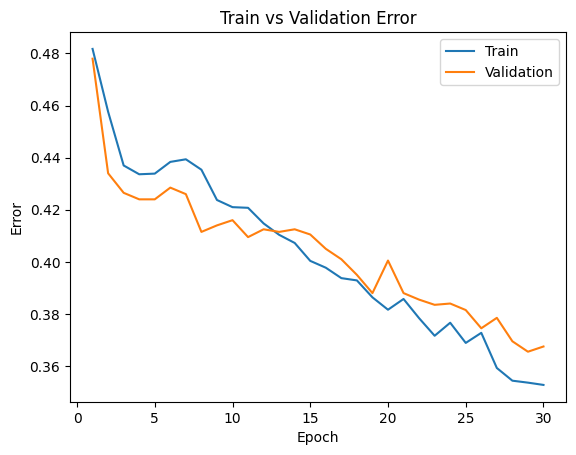

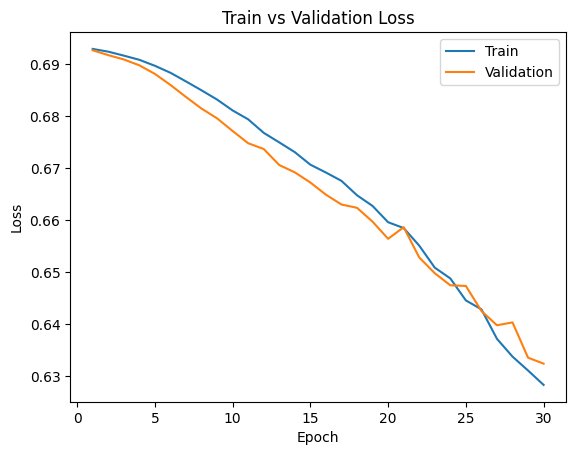

In [31]:
large_path = get_model_name("large", batch_size=512, learning_rate=0.01, epoch=29)

plot_training_curve(large_path)

Trained in about the same time. Validation and training loss are close, showing that the model generalizes well. Very smooth graphs thanks to less noise since batches are larger.

### Part (d) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.

In [32]:
large_net = LargeNet()
train_net(large_net, batch_size=16)

Epoch 1: Train err: 0.432625, Train loss: 0.6775384308099747 |Validation err: 0.379, Validation loss: 0.6511892986297607
Epoch 2: Train err: 0.36775, Train loss: 0.63936687707901 |Validation err: 0.353, Validation loss: 0.6177503232955932
Epoch 3: Train err: 0.3415, Train loss: 0.6115842840075493 |Validation err: 0.355, Validation loss: 0.6529891676902772
Epoch 4: Train err: 0.3135, Train loss: 0.5866389439702034 |Validation err: 0.3605, Validation loss: 0.6198044698238373
Epoch 5: Train err: 0.305375, Train loss: 0.5667855906486511 |Validation err: 0.3135, Validation loss: 0.5828237812519074
Epoch 6: Train err: 0.2845, Train loss: 0.5473563192486763 |Validation err: 0.3, Validation loss: 0.5852036819458007
Epoch 7: Train err: 0.2695, Train loss: 0.5275182847976685 |Validation err: 0.3035, Validation loss: 0.5836275753974914
Epoch 8: Train err: 0.2595, Train loss: 0.5122537192702293 |Validation err: 0.319, Validation loss: 0.5992895288467407
Epoch 9: Train err: 0.2535, Train loss: 0.49

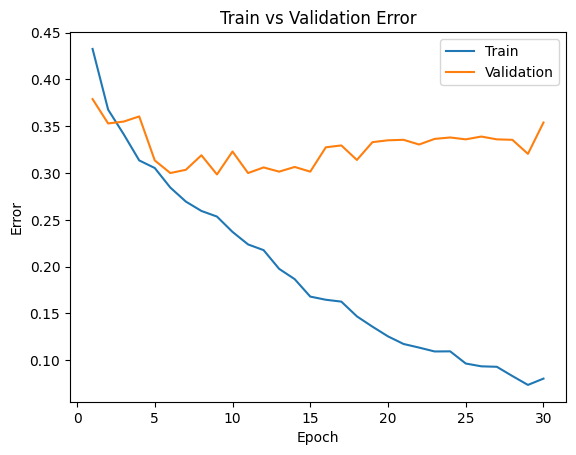

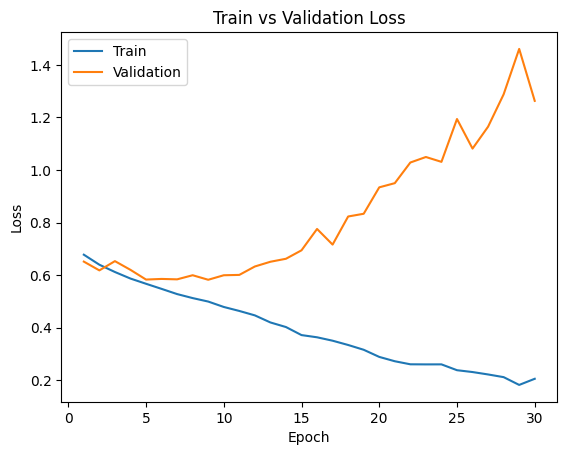

In [33]:
large_path = get_model_name("large", batch_size=16, learning_rate=0.01, epoch=29)

plot_training_curve(large_path)

Took longer to train. Dropping batch size causes the model to overfit rapidly.

## Part 4. Hyperparameter Search [6 pt]

### Part (a) - 2pt

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

In [40]:
batch_size = 512
learning_rate = 0.01

Using 512 and 0.01 showed the best results as they ensure that the model generalizes well. It performs similarly on training and validation data.

### Part (b) - 1pt

Train the model with the hyperparameters you chose in part(a), and include the training curve.

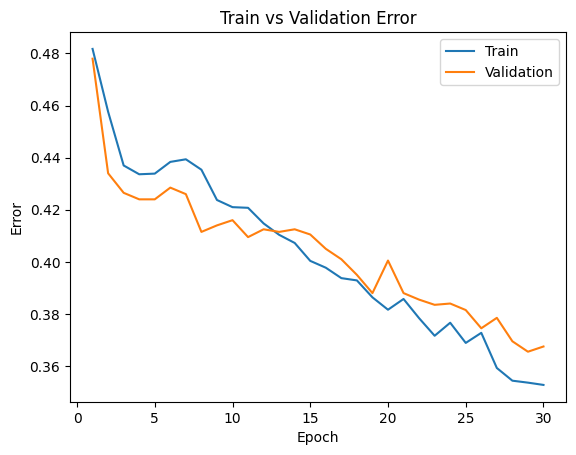

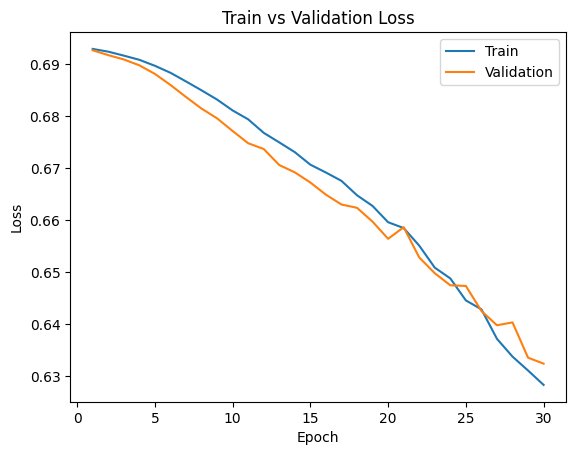

In [41]:
# Already trained
large_path = get_model_name("large", batch_size=batch_size, learning_rate=learning_rate, epoch=29)
plot_training_curve(large_path)

### Part (c) - 2pt

Based on your result from Part(a), suggest another set of hyperparameter values to try. 
Justify your choice.

In [46]:
batch_size = 512
learning_rate = 0.01
network = SmallNet()

Testing out a smaller model with same batch size and learning rate to see if it is able to overfit less and generalize even better.

### Part (d) - 1pt

Train the model with the hyperparameters you chose in part(c), and include the training curve.

In [47]:
train_net(network, batch_size=batch_size, learning_rate=learning_rate)

Epoch 1: Train err: 0.46325, Train loss: 0.6919051967561245 |Validation err: 0.426, Validation loss: 0.6849749386310577
Epoch 2: Train err: 0.424125, Train loss: 0.6836256198585033 |Validation err: 0.401, Validation loss: 0.6759902089834213
Epoch 3: Train err: 0.403375, Train loss: 0.6758348643779755 |Validation err: 0.401, Validation loss: 0.6686644852161407
Epoch 4: Train err: 0.3955, Train loss: 0.6692125760018826 |Validation err: 0.3895, Validation loss: 0.6631694287061691
Epoch 5: Train err: 0.395375, Train loss: 0.6644352488219738 |Validation err: 0.3855, Validation loss: 0.6603235155344009
Epoch 6: Train err: 0.390875, Train loss: 0.6608642563223839 |Validation err: 0.381, Validation loss: 0.6569485366344452
Epoch 7: Train err: 0.387625, Train loss: 0.6578126475214958 |Validation err: 0.3795, Validation loss: 0.6544083952903748
Epoch 8: Train err: 0.3775, Train loss: 0.6545666940510273 |Validation err: 0.375, Validation loss: 0.6543895155191422
Epoch 9: Train err: 0.371375, Trai

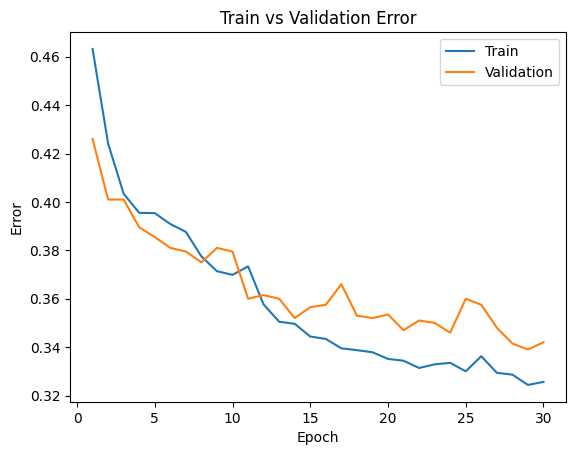

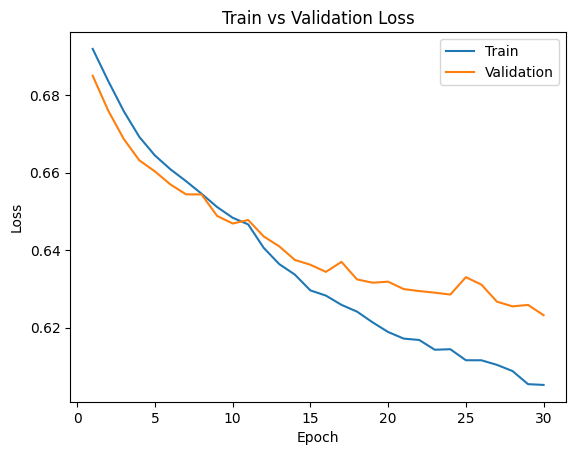

In [48]:
large_path = get_model_name("small", batch_size=batch_size, learning_rate=learning_rate, epoch=29)
plot_training_curve(large_path)

## Part 4. Evaluating the Best Model [15 pt]


### Part (a) - 1pt

Choose the **best** model that you have so far. This means choosing the best model checkpoint,
including the choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`, 
**and the epoch number**.

Modify the code below to load your chosen set of weights to the model object `net`.

In [51]:
net = LargeNet()
model_path = get_model_name(net.name, batch_size=512, learning_rate=0.01, epoch=29)
state = torch.load(model_path)
net.load_state_dict(state)

<All keys matched successfully>

### Part (b) - 2pt

Justify your choice of model from part (a).

It was the model that generalized the best.

### Part (c) - 2pt

Using the code in Part 0, any code from lecture notes, or any code that you write,
compute and report the **test classification error** for your chosen model.

In [53]:
criterion = nn.BCEWithLogitsLoss()

# Recreate loaders with the same batch size used for the chosen model
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"],
    batch_size=batch_size)

# Evaluate the chosen model on the test set
test_err, test_loss = evaluate(net, test_loader, criterion)

print(f"Test classification error: {test_err:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test classification error: 0.3550
Test loss: 0.6316


### Part (d) - 3pt

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.

The test classification error we computed for the chosen model is about 0.355 (35.5%).

We would expect the test error to be at least as high as, and usually a bit higher than, the validation error for two reasons:

- The validation set was used during model selection and hyperparameter tuning, so it is a somewhat optimistic estimate of performance.
- The test set is completely unseen until the very end, so it gives a more realistic measure of how well the model generalizes to new data.

In other words, the validation error is often slightly lower because the model and settings were chosen to perform well on that specific validation set, while the test error reflects true out-of-sample performance.

### Part (e) - 2pt

Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?

We only use the test set at the very end because it is supposed to be an unbiased final evaluation of the model. During training and model selection, we should use the training set and validation set so we can tune hyperparameters and compare models without “seeing” the test data.

It is important to use the test set as little as possible because:

- If we keep using it during development, we start to overfit to the test set itself.
- Repeated evaluation on the test set can make us accidentally choose a model that performs well only on that specific sample of data.
- The test set should represent a true unseen benchmark, so using it too often makes the reported performance overly optimistic and less reliable.

### Part (f) - 5pt

How does the your best CNN model compare with an 2-layer ANN model (no convolutional layers) on classifying cat and dog images. You can use a 2-layer ANN architecture similar to what you used in Lab 1. You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.

Hint: The ANN in lab 1 was applied on greyscale images. The cat and dog images are colour (RGB) and so you will need to flatted and concatinate all three colour layers before feeding them into an ANN.

In [56]:
torch.manual_seed(1000)

class ANN2Layer(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.name = "ann_2layer"
        self.fc1 = nn.Linear(32 * 32 * 3, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(1)

train_loader, val_loader, test_loader, _ = get_data_loader(
    target_classes=["cat", "dog"],
    batch_size=64
)

model = ANN2Layer(hidden_dim=128)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(3):
    model.train()
    total_loss = 0.0
    total_seen = 0

    for inputs, labels in train_loader:
        labels = normalize_label(labels)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_seen += len(labels)

    print(f"Epoch {epoch + 1:2d} | train_loss={total_loss / total_seen:.4f}")

ann_val_err, ann_val_loss = evaluate(model, val_loader, criterion)
ann_test_err, ann_test_loss = evaluate(model, test_loader, criterion)

cnn_val_err, cnn_val_loss = evaluate(net, val_loader, criterion)
cnn_test_err, cnn_test_loss = evaluate(net, test_loader, criterion)

print("\nQuick ANN vs CNN comparison:")
print(f"ANN val err: {ann_val_err:.4f} | ANN test err: {ann_test_err:.4f}")
print(f"ANN val loss: {ann_val_loss:.4f} | ANN test loss: {ann_test_loss:.4f}")
print(f"CNN val err: {cnn_val_err:.4f} | CNN test err: {cnn_test_err:.4f}")
print(f"CNN val loss: {cnn_val_loss:.4f} | CNN test loss: {cnn_test_loss:.4f}")


Epoch  1 | train_loss=0.6771
Epoch  2 | train_loss=0.6354
Epoch  3 | train_loss=0.6146

Quick ANN vs CNN comparison:
ANN val err: 0.3740 | ANN test err: 0.3575
ANN val loss: 0.6514 | ANN test loss: 0.6402
CNN val err: 0.3675 | CNN test err: 0.3550
CNN val loss: 0.6316 | CNN test loss: 0.6318
